## Customer Discount Dependency Analysis

### Context
The previous analysis (Notebook 1) established that:
- ~61% of transactions are discounted
- Discounting consistently reduces margin (~4–5 percentage points)
- Margin compression is uniform across categories and driven by transaction volume

This indicates that discounting is a **system-wide pricing mechanism**, not an isolated behavior.

---

### Purpose of This Notebook
This notebook shifts the analysis from **transaction-level behavior** to **customer-level behavior**.

The objective is to determine whether:
- Discounting is driven by **customer dependency**
- Or imposed uniformly regardless of customer behavior

---

### Key Questions
- How dependent are customers on discounted transactions?
- Do high-discount customers generate lower margins?
- Is there a behavioral difference (volume, frequency) across customer segments?
- Does customer behavior reinforce or explain the margin compression observed earlier?

---

### Analytical Approach
- Construct customer-level metrics from transaction data
- Segment customers based on discount dependency
- Compare margin and behavioral patterns across segments
- Validate whether discounting is customer-driven or structurally applied

---

### Assumptions
- Input dataset is validated and consistent with SQL outputs
- Discount definition remains: `netprice < unitprice` OR `netprice != unitprice`
- Margin is calculated at line level and averaged at customer level

---

### Limitations
- No customer lifetime value or retention analysis
- No causal inference (observational analysis only)
- Margin does not include operational or fixed costs

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# display settings
pd.set_option("display.max_columns", None)

### Load Data (from pickle)

In [2]:
df = pd.read_parquet("../data/processed/df_base.parquet")

df.shape

(223974, 22)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 223974 entries, 0 to 223973
Data columns (total 22 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   orderkey         223974 non-null  int64         
 1   quantity         223974 non-null  int8          
 2   unitprice        223974 non-null  float32       
 3   netprice         223974 non-null  float32       
 4   unitcost         223974 non-null  float32       
 5   customerkey      223974 non-null  int32         
 6   storekey         223974 non-null  int32         
 7   orderdate        223974 non-null  datetime64[ms]
 8   deliverydate     223974 non-null  datetime64[ms]
 9   categoryname     223974 non-null  category      
 10  subcategoryname  223974 non-null  category      
 11  age              223974 non-null  int8          
 12  gender           223974 non-null  category      
 13  occupation       223974 non-null  category      
 14  continent        223974 non-nul

In [4]:
df.head()

,orderkey,quantity,unitprice,netprice,unitcost,customerkey,storekey,orderdate,deliverydate,categoryname,subcategoryname,age,gender,occupation,continent,country,revenue,profit,margin_pct,is_discounted,discount_pct,discount_tier
0,139000,2,375.980011,375.980011,172.899994,1293529,430,2016-05-18,2016-05-18,TV and Video,Televisions,52,female,Extractive metallurgical engineer,North America,US,751.96,406.16,0.54,False,0.000000,Low Discount (<5%)
1,139000,8,7.790000,7.790000,3.970000,1293529,430,2016-05-18,2016-05-18,"Music, Movies and Audio Books",Movie DVD,52,female,Extractive metallurgical engineer,North America,US,62.32,30.56,0.49,False,0.000000,Low Discount (<5%)
2,139001,3,239.199997,227.240005,121.949997,915563,410,2016-05-18,2016-05-18,TV and Video,Home Theater System,21,female,Commercial loan officer,Europe,GB,681.72,315.87,0.46,True,5.000000,Low Discount (<5%)
3,139001,1,22.400000,22.400000,11.420000,915563,410,2016-05-18,2016-05-18,Games and Toys,Download Games,21,female,Commercial loan officer,Europe,GB,22.40,10.98,0.49,False,0.000000,Low Discount (<5%)
4,139002,2,114.720001,103.250000,58.490002,1133937,410,2016-05-18,2016-05-18,TV and Video,Televisions,45,female,Systems analyst,Europe,GB,206.50,89.52,0.43,True,9.998257,Moderate Discount (5-10%)


### Data Validation Check

- Dataset successfully loaded from processed layer
- Structure matches Notebook 1 output
- All derived columns (e.g., `discount_pct`, `margin_pct`, `is_discounted`) are present

Any inconsistency at this stage would invalidate downstream analysis.

### Customer-Level Metric Construction

To analyze discount dependency, transaction-level data is aggregated to the customer level.

Each customer is represented by:
- Total number of order lines (activity level)
- Percentage of discounted transactions (discount dependency)
- Average margin across transactions (profitability)

This creates the base dataset for segmentation and comparison.

In [5]:
customer_df = (
    df.groupby("customerkey")
    .agg(
        total_order_lines=("customerkey", "size"),
        discount_pct=("is_discounted", "mean"),   
        avg_margin=("margin_pct", "mean")
    )
    .reset_index()
)

# convert to percentage
customer_df["discount_pct"] = customer_df["discount_pct"] * 100

customer_df.round(2).head()

,customerkey,total_order_lines,discount_pct,avg_margin
0,15,5,100.00,0.59
1,180,2,50.00,0.50
2,185,2,100.00,0.42
3,311,3,66.67,0.53
4,385,2,50.00,0.50


### Customer Segmentation by Discount Dependency

Customers are segmented based on the percentage of discounted transactions:

- High: ≥ 75%
- Medium: 50–75%
- Low: < 50%

This allows comparison of profitability and behavior across distinct customer groups.

In [6]:
customer_df["discount_segment"] = pd.cut(
    customer_df["discount_pct"],
    bins=[-np.inf, 50, 75, np.inf],
    labels=["Low", "Medium", "High"]
)

segment_summary = (
    customer_df
    .groupby("discount_segment", observed=True)
    .agg(
        customer_count=("customerkey", "count"),
        avg_discount_pct=("discount_pct", "mean"),
        avg_margin=("avg_margin", "mean"),
        avg_order_lines=("total_order_lines", "mean")
    )
    .reindex(["High", "Medium", "Low"])
    .round(2)
)

segment_summary

,customer_count,avg_discount_pct,avg_margin,avg_order_lines
discount_segment,,,,
High,16095,96.07,0.50,3.20
Medium,14758,66.40,0.52,6.23
Low,21336,30.92,0.53,3.77


### Observation
- Customer distribution skews toward the Low-discount segment: ~21K Low, ~16K High, ~14.7K Medium.
- Segment behaviour aligns with definitions: High: ~96% of transactions discounted, Medium: ~66%, Low: ~31%.
- Margin declines consistently with discount dependency: Low: ~53%, Medium: ~52%, High: ~50%.
- Medium-discount customers show the highest engagement at ~6.23 order lines per customer, compared to ~3.2–3.8 for the other segments.

### Insight
- The inverse relationship between discount dependency and margin holds at the customer level, confirming earlier transaction-level findings from Notebook 1.
- Medium-discount customers represent the most economically efficient segment, the highest purchase activity combined with controlled margin compression, making them the most commercially productive group.
- High-discount customers exhibit structural dependency on discounting, contributing to margin erosion without a corresponding increase in engagement or purchase frequency.
- The concentration of customers at the High and Low extremes, rather than a gradual distribution, indicates behavioural polarisation. Customers are not moderately discount-influenced; they either transact almost entirely on discount or almost entirely at full price.
- This polarisation reinforces the systemic nature of discounting: it is not functioning as a targeted tactical lever but as a structural feature of customer purchasing behaviour.

### Distribution of Customer Discount Dependency

Average values can hide underlying patterns.  
To better understand customer behavior, the distribution of discount usage is examined.

This helps determine whether:
- Customers form clear behavioral segments  
- Or exist along a continuous spectrum of discount dependency

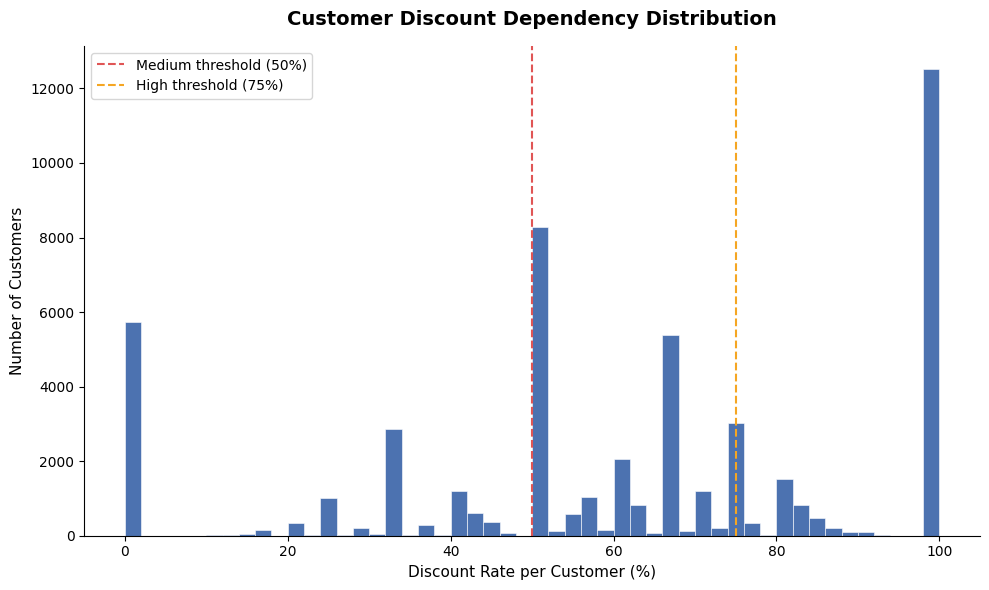

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(customer_df["discount_pct"], bins=50, color="#4C72B0", edgecolor="white", linewidth=0.4)

ax.axvline(50, color="#e05555", linewidth=1.5, linestyle="--", label="Medium threshold (50%)")
ax.axvline(75, color="#f5a623", linewidth=1.5, linestyle="--", label="High threshold (75%)")

ax.set_title("Customer Discount Dependency Distribution", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Discount Rate per Customer (%)", fontsize=11)
ax.set_ylabel("Number of Customers", fontsize=11)

ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(r"D:\data-analysis-projects\retail-discount-profitability-audit\exports\customer_discount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation
- The distribution is right-skewed with the dominant concentration at 100%, 
  indicating that the largest single customer group transacts almost exclusively 
  on discounted prices.
- A secondary cluster appears near 50%, representing customers with mixed 
  purchasing behaviour, roughly half discounted, half full-price.
- A smaller concentration near 0% reflects customers who rarely or never 
  purchase on discount.
- The overall shape confirms that discount-dependent behaviour is not an outlier 
  , it is the modal customer pattern in this dataset, structurally anchoring a 
  significant portion of demand to discounted pricing.

## Do High-Discount Customers Generate Lower Margins?

**Objective:** Validate whether the margin compression observed at the transaction 
level persists when analysis is shifted to the customer level and confirm that 
observed differences reflect genuine behavioural patterns rather than aggregation 
artefacts.

**Approach:**
- Compare average margin across the three customer discount segments
- Assess whether the margin gap between segments is consistent and directional
- Cross-reference with transaction volume to rule out distribution effects

In [18]:
segment_margin = (
    customer_df
    .groupby("discount_segment")
    .agg(
        avg_margin=("avg_margin", "mean"),
        customer_count=("customerkey", "count")
    )
    .round(4)
    .sort_values("avg_margin", ascending=False)
)

segment_margin

,avg_margin,customer_count
discount_segment,,
Low,0.5348,21336
Medium,0.5172,14758
High,0.5038,16095


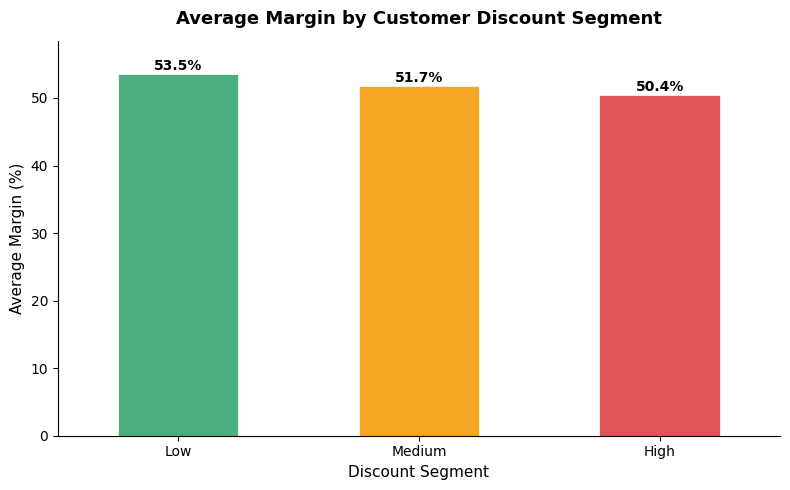

In [22]:
colors = ["#4caf82", "#f5a623", "#e05555"]

# multiplication by 100 for plotting
segment_margin["avg_margin"] = segment_margin["avg_margin"] * 100

fig, ax = plt.subplots(figsize=(8, 5))
segment_margin["avg_margin"].plot(kind="bar", ax=ax, color=colors, edgecolor="white", linewidth=0.5, width=0.5)

ax.set_title("Average Margin by Customer Discount Segment", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Discount Segment", fontsize=11)
ax.set_ylabel("Average Margin (%)", fontsize=11)
ax.tick_params(axis="x", rotation=0)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0, segment_margin["avg_margin"].max() + 5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(r"D:\data-analysis-projects\retail-discount-profitability-audit\exports\customer_segment_margin.png", dpi=150, bbox_inches="tight")
plt.show()

### Observation
- Average margin declines consistently across segments: Low: 53.5%, Medium: 51.7%, High: 50.4%.
- The gap between the Low and High segments is 3.1 percentage points.
- The decline is strictly monotonic with no reversals, and customer counts remain substantial across all three segments, confirming results are not driven by small or unrepresentative samples.

### Insight
- Margin compression persists at the customer level, not just at the transaction level, confirming that discount dependency has a measurable impact on overall customer economics.
- The monotonic decline across segments indicates a systematic pricing effect rather than segment-specific anomalies, each incremental increase in discount dependency corresponds to a directional reduction in realised margin.
- Combined with the engagement finding from the segmentation analysis, a clearer pattern emerges: discounting increases purchase activity up to a threshold (Medium segment), beyond which additional discount dependency continues to erode margin without generating proportional gains in frequency or volume.
- This confirms that discounting is operating as a broad pricing mechanism rather than a targeted behavioural lever, its effects are structural and consistent across the customer base.

### Is there a behavioral difference (volume, frequency) across customer segments?
- Compare engagement levels across Low, Medium, and High discount segments
- Determine whether discount dependency correlates with higher purchase activity
- Validate whether margin trade-offs are offset by increased customer engagement

In [23]:
behavior_df = (
    customer_df
    .groupby("discount_segment")
    .agg(
        avg_order_lines=("total_order_lines", "mean"),
        median_order_lines=("total_order_lines", "median"),
        customer_count=("customerkey", "count")
    )
    .round(2)
)

behavior_df

,avg_order_lines,median_order_lines,customer_count
discount_segment,,,
Low,3.77,3.0,21336
Medium,6.23,5.0,14758
High,3.20,2.0,16095


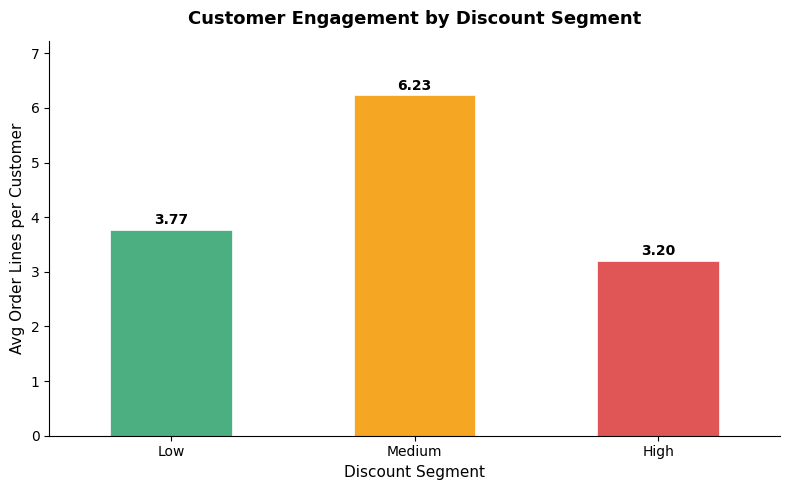

In [25]:
colors = ["#4caf82", "#f5a623", "#e05555"]

fig, ax = plt.subplots(figsize=(8, 5))
behavior_df["avg_order_lines"].plot(kind="bar", ax=ax, color=colors, edgecolor="white", linewidth=0.5, width=0.5)

ax.set_title("Customer Engagement by Discount Segment", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Discount Segment", fontsize=11)
ax.set_ylabel("Avg Order Lines per Customer", fontsize=11)
ax.tick_params(axis="x", rotation=0)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0, behavior_df["avg_order_lines"].max() + 1)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(r"D:\data-analysis-projects\retail-discount-profitability-audit\exports\customer_segment_engagement.png", dpi=150, bbox_inches="tight")
plt.show()

### Observation
- Medium-discount customers show the highest engagement: 6.23 average order lines
  per customer (median: 5).
- Low and High segments are significantly lower: Low: 3.77 average (median: 3),
  High: 3.20 average (median: 2).
- High-discount customers have the lowest purchase frequency of all three segments.

### Insight
- Engagement follows an inverted-U pattern: discounting increases purchase activity
  up to a threshold (Medium segment), beyond which frequency declines despite
  continued discount dependency.
- High-discount customers are not high-value in volume terms, they are high only
  in discount reliance. The margin erosion they produce is not offset by
  proportionally higher activity.
- The Medium segment represents the most commercially balanced profile: the highest
  engagement alongside controlled margin compression, making it the segment where
  discounting most closely approximates a productive pricing lever.

### Is discounting customer-driven or structurally applied?
- Analyze distribution of customer discount rates
- Check whether behavior is concentrated (clusters) or evenly distributed
- Determine if discounting reflects selective targeting or system-wide pricing behavior

In [27]:
dist_summary = customer_df["discount_pct"].describe().round(2)

dist_summary

count    52189.00
mean        61.04
std         30.92
min          0.00
25%         46.67
50%         64.29
75%         85.71
max        100.00
Name: discount_pct, dtype: float64

In [30]:
low_extreme = (customer_df["discount_pct"] <= 10).mean() * 100
high_extreme = (customer_df["discount_pct"] >= 90).mean() * 100

print(f"Customers with ≤10% discount rate: {low_extreme:.1f}%")
print(f"Customers with ≥90% discount rate: {high_extreme:.1f}%")

Customers with ≤10% discount rate: 11.0%
Customers with ≥90% discount rate: 24.2%


### Observation
- Average customer discount rate is ~61%, with a wide spread (std: ~31%)
- Median (64%) is close to mean, indicating discounting is broadly applied, not skewed by outliers
- Only ~11% of customers operate near full-price behavior (≤10% discount usage)
- A significantly larger group (~24%) operates almost entirely on discounts (≥90%)

### Insight
- Customer behavior is **not normally distributed**; it is **skewed toward high discount usage**
- The presence of a large near-100% discount group confirms that a meaningful portion of customers **consistently depend on discounted pricing**
- Since low-discount customers are a minority, discounting cannot be explained purely by selective targeting
- This validates that discounting is **structurally embedded in the pricing system**, not just customer-driven behavior

### Exporting Customers Data

In [32]:
customer_df.to_parquet(
    r"D:\data-analysis-projects\retail-discount-profitability-audit\data\processed\customer_segments.parquet",
    index=False
)
print(f"Exported: {len(customer_df):,} customers -> data/processed/customer_segments.parquet")

Exported: 52,189 customers -> data/processed/customer_segments.parquet


---

## Notebook Summary

### Purpose

This notebook elevated the analysis from transaction-level behavior to customer-level behavior, examining whether discount-driven margin compression is explained by customer purchasing patterns or by a structurally applied pricing mechanism.

---

### What Was Completed

**Customer Profile Construction:** A customer-level dataframe was built from 223,974 transaction lines across 52,189 unique customers, aggregating total order lines, discount dependency rate, and average margin per customer.

**Segmentation:** Customers were segmented into three groups by discount dependency: Low (<50%), Medium (50–75%), and High (≥75%), producing a behaviorally distinct partition with substantial counts in each group.

**Margin Validation:** Average margin was compared across segments and confirmed to decline monotonically: Low: 53.5%, Medium: 51.7%, High: 50.4%. The 3.1 percentage point gap between the extremes confirms that margin compression persists at the customer level, not just at the transaction level.

**Engagement Analysis:** Purchase frequency follows an inverted-U pattern across segments. Medium-discount customers show the highest activity at 6.23 average order lines per customer, nearly double the High segment (3.20). This confirms that deeper discounting does not generate proportionally higher engagement.

**Distribution Analysis:** Customer discount rates are right-skewed, with a mean of 61% and a median of 64%. A significant 24.2% of customers operate at ≥90% discount usage, while only 11% transact near full price. This polarised distribution rules out selective targeting as the primary explanation for discounting prevalence.

---

### Key Validated Findings

- Margin compression is not an artifact of transaction-level aggregation, it holds consistently when measured at the customer level across all three segments.
- The Medium-discount segment is the most commercially productive: highest purchase frequency with only moderate margin compression, indicating that discounting functions as an effective engagement lever up to a threshold.
- High-discount customers represent a structurally dependent segment, they do not compensate for margin erosion through increased activity, making them the least efficient customer group in the dataset.
- The distribution of customer discount rates confirms that discounting is embedded in the pricing system rather than driven by individual customer behavior or targeted promotional strategy.

---

### What Comes Next

The following notebook examines store-level and geographic discount behavior, investigating whether pricing patterns vary by location or channel, or whether the structural uniformity observed at the transaction and customer level extends across the entire store network.